CGRE (new tables from Louisa):

- Transfer nucleotide to aminos → aa genotypes
- Get mean of means and sum of stds (as for 1 amino can be several nucleotides)
- Take delta from wt
- Recount epistasis like Olga said

4 cgre variants in total.

In [1]:
import pandas as pd
import numpy as np

def table_parser(df):
    # Group by aa_genotype
    grouped = df.groupby("aa_genotype")
    # Calculate the mean brightness and standard deviation of brightness
    result = grouped[["brightness", "brightness_stdev"]].apply(
    lambda group: pd.Series({
        "brightness": group["brightness"].mean(),
        "brightness_stdev": np.sqrt(np.sum(group["brightness_stdev"] ** 2)) / len(group)
    })
    ).reset_index()
    # Calculate delta from wt and remove it 
    wt_brightness = result.loc[result["aa_genotype"] == "wt", "brightness"].values[0]
    wt_brightness_stdev = result.loc[result["aa_genotype"] == "wt", "brightness_stdev"].values[0]
    result["brightness"] = result["brightness"] - wt_brightness
    result["brightness_stdev"] = np.sqrt(result["brightness_stdev"] ** 2 + wt_brightness_stdev ** 2)
    result = result[~result["aa_genotype"].str.contains("wt", case=False, na=False)].reset_index(drop=True)
    # Calculate the number of mutations
    result["num_mutations"] = result["aa_genotype"].apply(lambda x: len(x.split(":")))
    return result

In [6]:
import os
import pandas as pd

directory = "data/errors_cgre"

for file in os.listdir(directory):
    file_path = os.path.join(directory, file)
    name = file.split("_")[3]
    df = pd.read_csv(file_path)
    df = table_parser(df)

    singles = df[df['num_mutations'] == 1].copy()
    multi = df[df['num_mutations'] > 1].copy()

    # Explicitly create new columns on a copy
    multi["sum_brightness"] = pd.NA
    multi["valid"] = pd.NA

    for i, row in multi.iterrows():
        muts = row["aa_genotype"].split(":")
        sum_brightness = 0
        missing = False

        for mut in muts:
            match = singles[singles["aa_genotype"] == mut]
            if match.empty:
                missing = True
                break
            sum_brightness += match["brightness"].values[0]

        if missing:
            continue

        multi.loc[i, "sum_brightness"] = sum_brightness

        # Compute sum of standard deviations
        sum_errors = sum(
            singles[singles["aa_genotype"] == mut]["brightness_stdev"].values[0] for mut in muts
        )

        # Apply epistasis condition
        is_valid = abs(row["brightness"] - sum_brightness) > sum_errors
        multi.loc[i, "valid"] = is_valid

    # Save result
    multi.to_csv(f"data/errors_cgre/{name}_to_plot.csv", index=False)

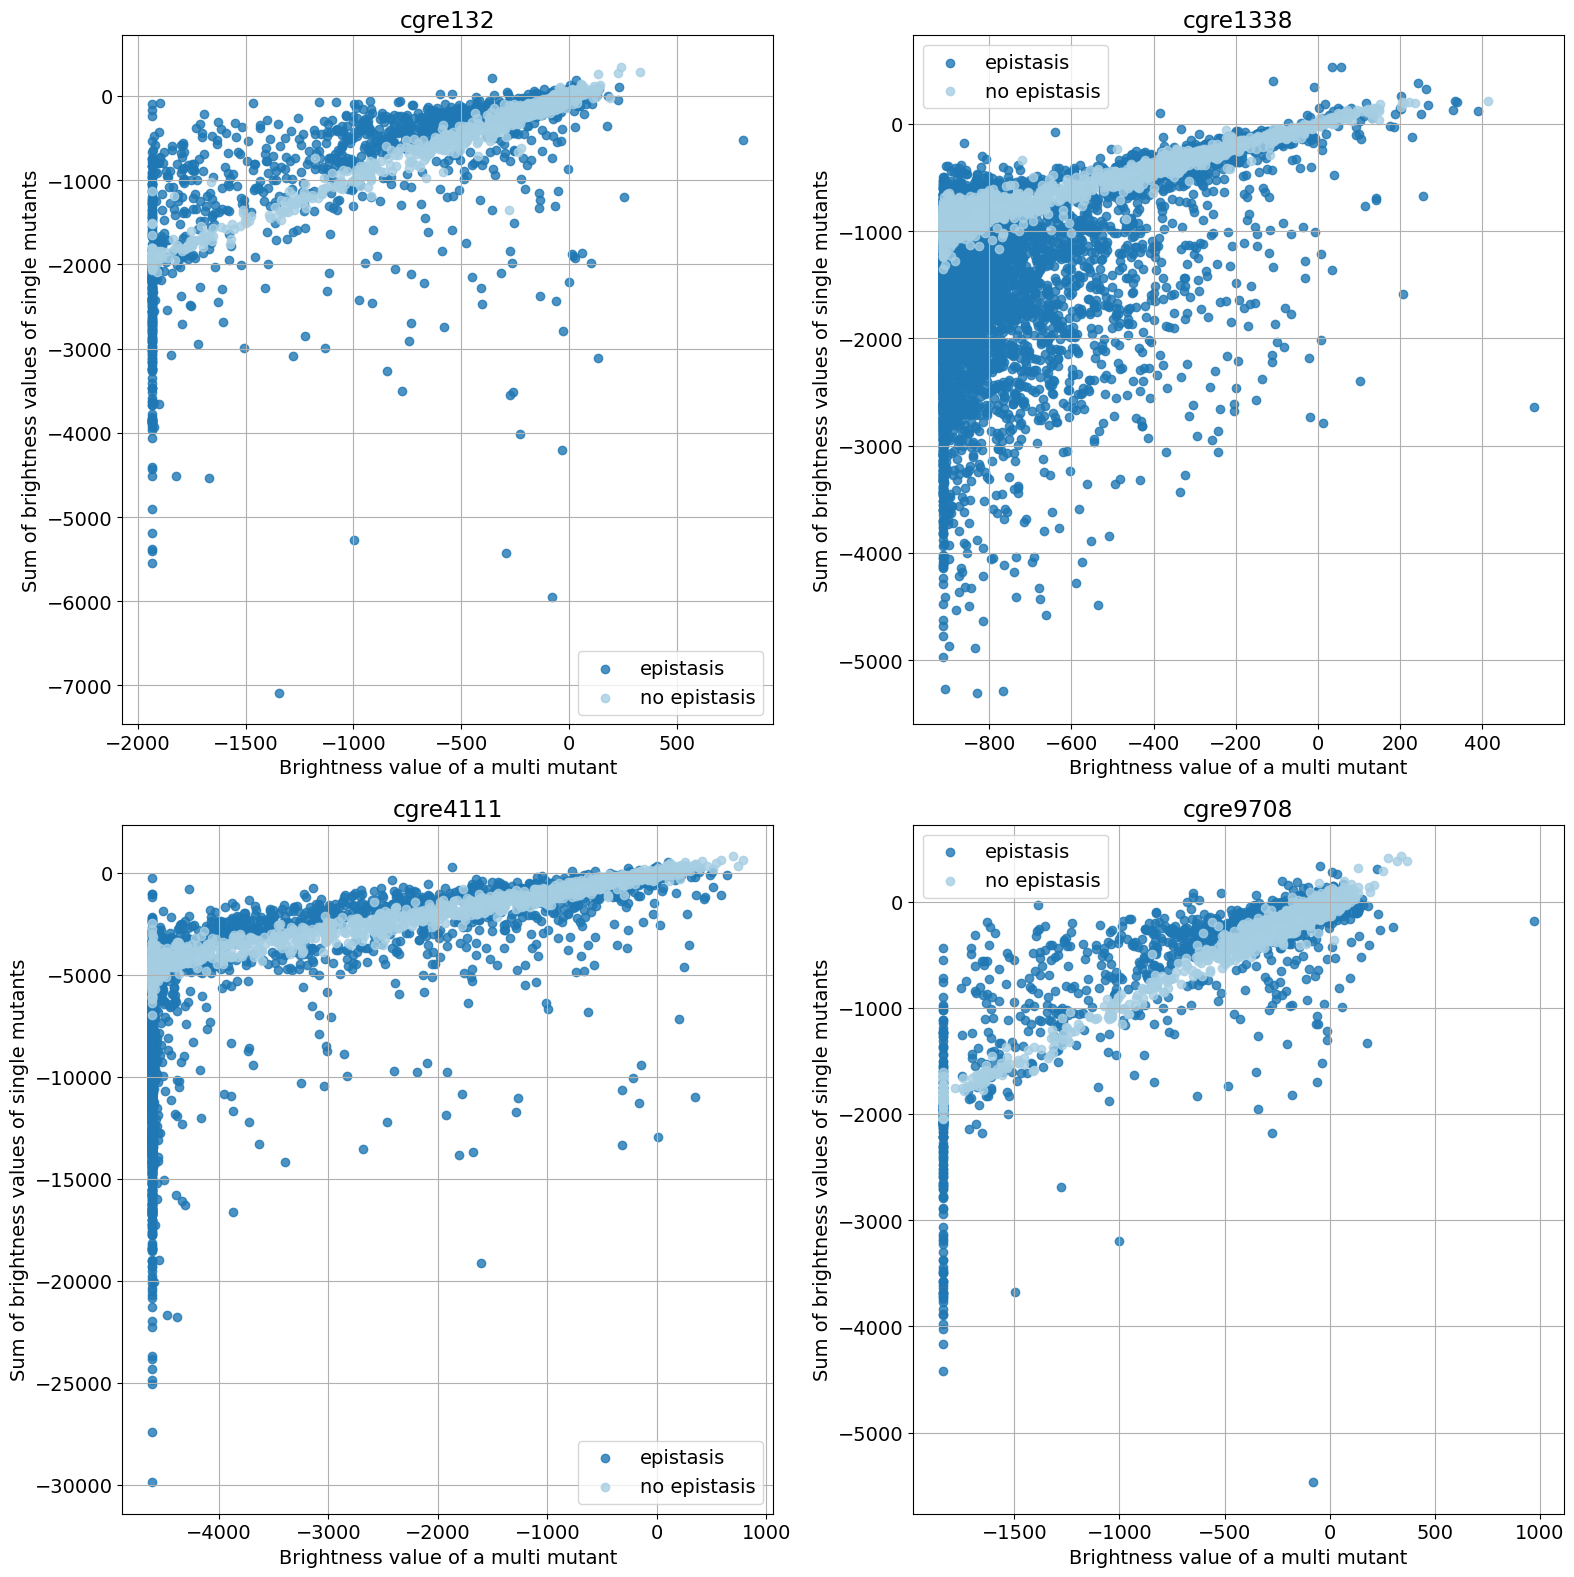

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

directory = "data/errors_cgre"
files = ["cgre132_to_plot.csv", "cgre1338_to_plot.csv",
         "cgre4111_to_plot.csv", "cgre9708_to_plot.csv"]
for index, file in enumerate(files):
    file_path = os.path.join(directory, file)
    name = file.split("_")[0]
    
    df = pd.read_csv(file_path)
    x = df[df["valid"] == True]['brightness'].values
    y = df[df["valid"] == True]['sum_brightness'].values
    distinct_x = df[df["valid"] == False]['brightness'].values
    distinct_y = df[df["valid"] == False]['sum_brightness'].values

    i = index // 2
    j = index % 2
    cmap = plt.get_cmap('Paired')
    axes[i, j].scatter(x, y, color=cmap(1), alpha=0.8, label='epistasis')
    axes[i, j].scatter(distinct_x, distinct_y, color=cmap(0), alpha=0.8, label='no epistasis')
    axes[i, j].set_title(f'{name}')
    axes[i, j].set_xlabel('Brightness value of a multi mutant')
    axes[i, j].set_ylabel('Sum of brightness values of single mutants')
    axes[i, j].legend()
    axes[i, j].grid(True)
plt.tight_layout()
plt.savefig(f'figures/dotplots/cgre_variants.png')

# Somermeyer GFP using std values

In [11]:
import os

# change to your working directory
os.chdir("/wibicomfs/STBS/anastasia/epistasis_prediction_review")

In [12]:
import pandas as pd
import numpy as np

def table_parser(df):
    # Group by aa_genotype
    grouped = df.groupby("aa_genotype")
    # Calculate the mean brightness and standard deviation of brightness
    result = grouped[["brightness", "brightness_stdev"]].apply(
    lambda group: pd.Series({
        "brightness": group["brightness"].mean(),
        "brightness_stdev": np.sqrt(np.sum(group["brightness_stdev"] ** 2)) / len(group)
    })
    ).reset_index()
    # Calculate delta from wt and remove it 
    wt_brightness = result.loc[result["aa_genotype"] == "wt", "brightness"].values[0]
    wt_brightness_stdev = result.loc[result["aa_genotype"] == "wt", "brightness_stdev"].values[0]
    result["brightness"] = result["brightness"] - wt_brightness
    result["brightness_stdev"] = np.sqrt(result["brightness_stdev"] ** 2 + wt_brightness_stdev ** 2)
    result = result[~result["aa_genotype"].str.contains("wt", case=False, na=False)].reset_index(drop=True)
    # Calculate the number of mutations
    result["num_mutations"] = result["aa_genotype"].apply(lambda x: len(x.split(":")))
    return result

In [13]:
import os
import pandas as pd

main_df = pd.read_csv("data/errors_cgre/amacGFP_cgreGFP_ppluGFP2__final_nucleotide_genotypes_to_brightness.csv")
main_df.rename(columns={"aa_genotype_native": "aa_genotype",
                        "replicates_mean_brightness": "brightness",
                        "replicates_stdev_weighted": "brightness_stdev"}, inplace=True)
proteins = ["ppluGFP", "cgreGFP", "amacGFP"]
for protein in proteins:
    df = main_df[main_df["gene"] == protein].copy()
    df = table_parser(df)

    singles = df[df['num_mutations'] == 1].copy()
    multi = df[df['num_mutations'] > 1].copy()

    # Explicitly create new columns on a copy
    multi["sum_brightness"] = pd.NA
    multi["valid"] = pd.NA

    for i, row in multi.iterrows():
        muts = row["aa_genotype"].split(":")
        sum_brightness = 0
        missing = False

        for mut in muts:
            match = singles[singles["aa_genotype"] == mut]
            if match.empty:
                missing = True
                break
            sum_brightness += match["brightness"].values[0]

        if missing:
            continue

        multi.loc[i, "sum_brightness"] = sum_brightness

        # Compute sum of standard deviations
        sum_errors = sum(
            singles[singles["aa_genotype"] == mut]["brightness_stdev"].values[0] for mut in muts
        )

        # Lower bound for sum_brightness
        sum_brightness = max(sum_brightness, min(multi["brightness"]))

        # Apply epistasis condition
        is_valid = abs(row["brightness"] - sum_brightness) > 2*sum_errors
        multi.loc[i, "valid"] = is_valid

    # Save result
    multi.to_csv(f"data/errors_cgre/{protein}_to_plot.csv", index=False)

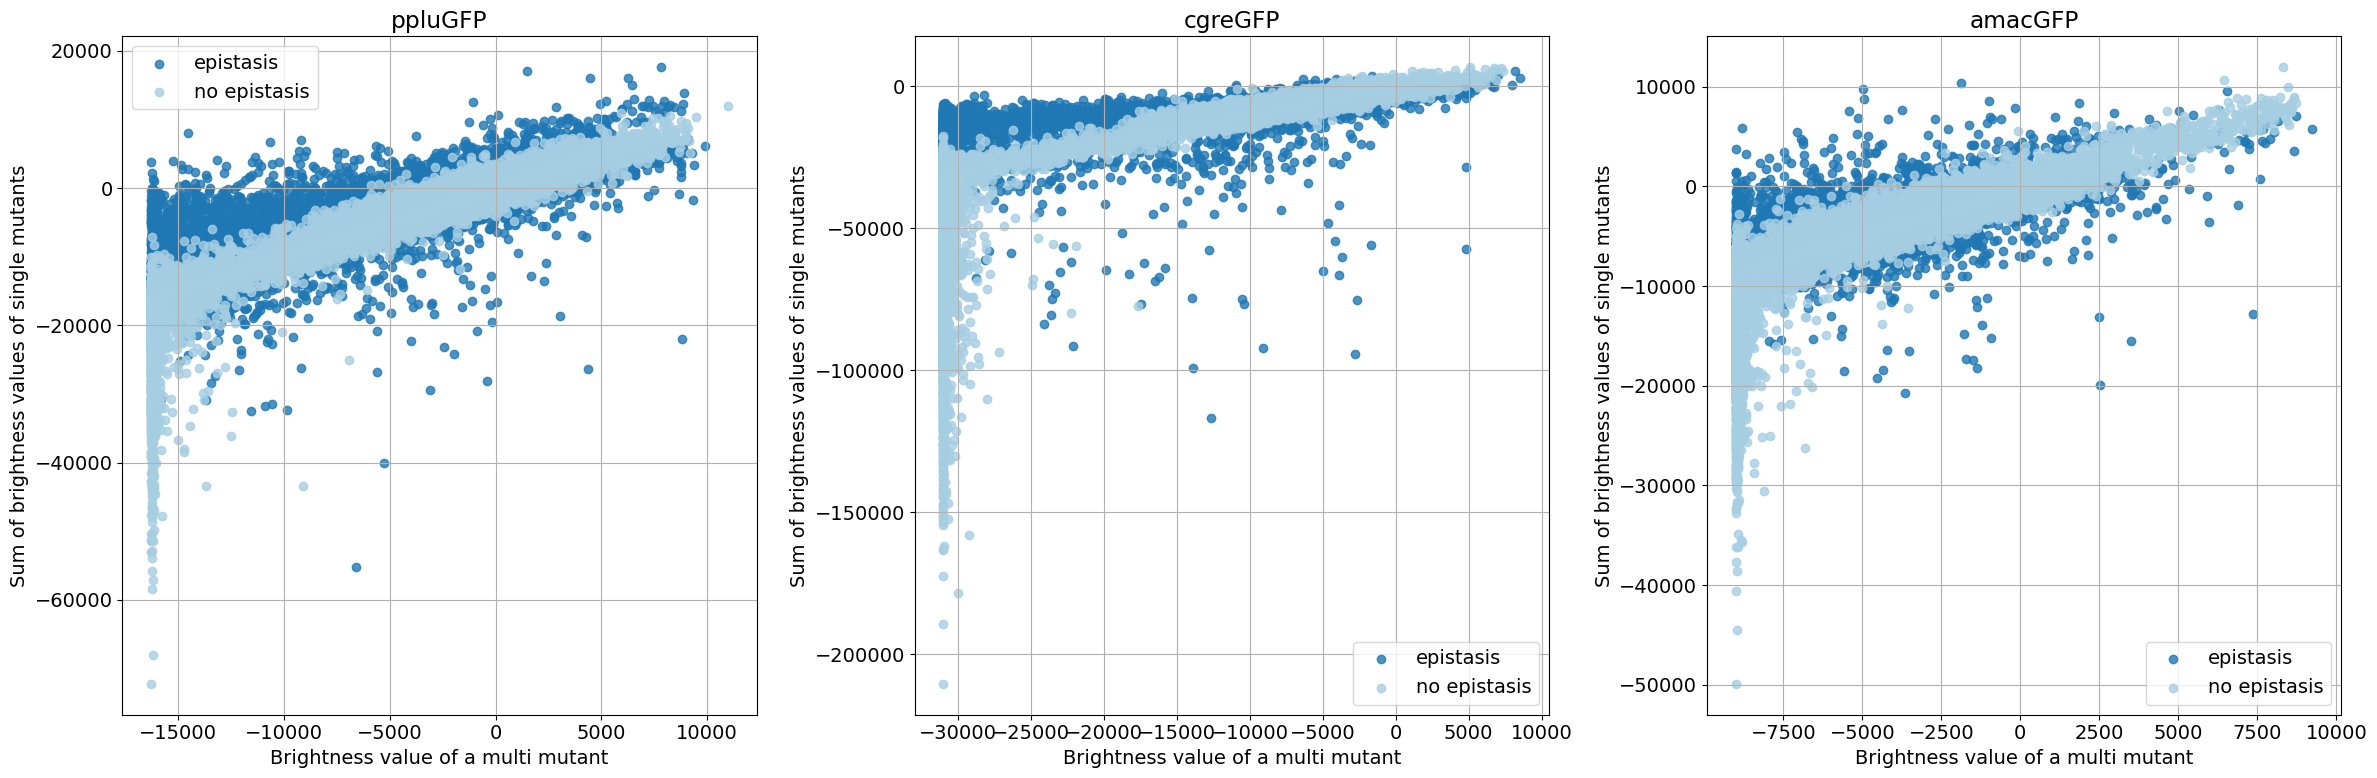

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8))

directory = "data/errors_cgre"
files = ["ppluGFP_to_plot.csv", "cgreGFP_to_plot.csv", "amacGFP_to_plot.csv"]
for index, file in enumerate(files):
    file_path = os.path.join(directory, file)
    name = file.split("_")[0]
    
    df = pd.read_csv(file_path)
    x = df[df["valid"] == True]['brightness'].values
    y = df[df["valid"] == True]['sum_brightness'].values
    distinct_x = df[df["valid"] == False]['brightness'].values
    distinct_y = df[df["valid"] == False]['sum_brightness'].values

    cmap = plt.get_cmap('Paired')
    axes[index].scatter(x, y, color=cmap(1), alpha=0.8, label='epistasis')
    axes[index].scatter(distinct_x, distinct_y, color=cmap(0), alpha=0.8, label='no epistasis')
    axes[index].set_title(f'{name}')
    axes[index].set_xlabel('Brightness value of a multi mutant')
    axes[index].set_ylabel('Sum of brightness values of single mutants')
    axes[index].legend()
    axes[index].grid(True)
plt.tight_layout()
plt.savefig(f'figures/dotplots/somermeyer.png')

### Violin plots

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# change to your working directory
os.chdir("/wibicomfs/STBS/anastasia/epistasis_prediction_review")

In [16]:
dfs = {}
directory = 'data/ProteinGym_subs_apr_2024'
cols = ['model']

for filename in os.listdir(directory): # iterate over datasets
    if filename == 'D7PM05_CLYGR_Somermeyer_2022.csv' or filename == 'Q6WV13_9MAXI_Somermeyer_2022.csv' or filename == 'Q8WTC7_9CNID_Somermeyer_2022.csv':
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        dataset = filename.split('.')[0]
        dfs[dataset] = df
        cols.append(dataset + '_all')
        cols.append(dataset + '_epistatic')
result_all = pd.DataFrame(columns=cols)

In [17]:
from scipy.stats import spearmanr
import re

def shift_mutation_positions_up(mutant_str):
    if pd.isna(mutant_str):
        return mutant_str
    mutations = mutant_str.split(':')
    shifted = []
    for m in mutations:
        match = re.match(r"([A-Z])(\d+)([A-Z])", m)
        if match:
            aa_from, pos, aa_to = match.groups()
            shifted_pos = str(int(pos) + 1)
            shifted.append(f"{aa_from}{shifted_pos}{aa_to}")
        else:
            shifted.append(m)
    return ':'.join(shifted)

def calculate_spearman(result_all, entry_path, model):
    score_columns = []
    score_indices = {}
    for filename in os.listdir(entry_path): # let's just open 1 file and check if there're several rows with predictions (different num of parameters)
        file_path = os.path.join(entry_path, filename)
        dataset = filename.split('.')[0]
        if dataset in dfs: 
            df = dfs[dataset]
            df_pred = pd.read_csv(file_path)
            for col in df_pred.columns:
                if ('mut' not in col) and ('seq' not in col) and ('DMS_score' not in col):
                    score_columns.append(col)
            break
    for score_column in score_columns:
        new_row = pd.DataFrame(dict(zip(list(result_all.columns), [model + '_' + score_column] + [None]*(result_all.shape[1] - 1))), index=[0])
        result_all = pd.concat([result_all, new_row], ignore_index=True) # SAVE INDICES + SCORE NAMES IN A DICT TO APPEND AFTERWARDS
        score_indices[score_column] = result_all.index[-1]
    for filename in os.listdir(entry_path): # iterate over datasets
        file_path = os.path.join(entry_path, filename)
        dataset = filename.split('.')[0]
        if dataset == 'Q6WV12_9MAXI_Somermeyer_2022':
            dataset = 'Q6WV13_9MAXI_Somermeyer_2022'
        if dataset in dfs: 
            df = dfs[dataset]
            df_pred = pd.read_csv(file_path)
            if 'mutant' in df_pred.columns:
                if 'DMS_score' in df_pred.columns:
                    merged_df = df.merge(df_pred, left_on=['mutant', 'DMS_score'], right_on=['mutant', 'DMS_score'])
                else:
                    merged_df = df.merge(df_pred, left_on='mutant', right_on='mutant')
            else:
                if 'DMS_score' in df_pred.columns:
                    merged_df = df.merge(df_pred, left_on=['mutated_sequence', 'DMS_score'], right_on=['mutated_sequence', 'DMS_score'])
                else:
                    merged_df = df.merge(df_pred, left_on='mutated_sequence', right_on='mutated_sequence')

            if dataset == 'D7PM05_CLYGR_Somermeyer_2022':
                to_plot = pd.read_csv('data/errors_cgre/cgreGFP_to_plot.csv')
            if dataset == 'Q6WV13_9MAXI_Somermeyer_2022':
                to_plot = pd.read_csv('data/errors_cgre/ppluGFP_to_plot.csv')
            if dataset == 'Q8WTC7_9CNID_Somermeyer_2022':
                to_plot = pd.read_csv('data/errors_cgre/amacGFP_to_plot.csv')

            to_plot.rename(columns={"aa_genotype": "mutant"}, inplace=True)
            to_plot['mutant'] = to_plot['mutant'].apply(shift_mutation_positions_up)
            merged_df = merged_df.merge(to_plot, on='mutant', how='left')
            for score_column in score_columns: # calculate for all predicted scores
                spearman_all = spearmanr(merged_df['DMS_score'], merged_df[score_column])[0]
                result_all.loc[score_indices[score_column], dataset + '_all'] = f"{spearman_all:.2f}"

                filtered = merged_df[merged_df["valid"].notna() & merged_df["valid"]]
                subset = filtered[["DMS_score", score_column]].dropna()
                spearman_epistatic = spearmanr(subset["DMS_score"], subset[score_column])[0]
                print("Number of epistatic points for", dataset, ":", len(subset))
                result_all.loc[score_indices[score_column], dataset + '_epistatic'] = f"{spearman_epistatic:.2f}"
    return result_all

In [18]:
directory = 'data/zero_shot_substitutions_scores'
for model in os.listdir(directory): # iterate over models
    entry_path = os.path.join(directory, model)
    if any(os.path.isdir(os.path.join(entry_path, entry)) for entry in os.listdir(entry_path)): # case when there are subfolders inside a model (different parameter number)
        for folder_name in os.listdir(entry_path): # iterate over submodels
            folder_path = os.path.join(entry_path, folder_name)
            result_all = calculate_spearman(result_all, folder_path, model + '_' + folder_name)
    else: # standart case
        result_all = calculate_spearman(result_all, entry_path, model)
result_all.to_csv('somermeyer_all_models.csv')

Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 3818
Number of epistatic points for Q6WV13_9MAXI_Somermeyer_2022 : 5747
Number of epistatic points for Q8WTC7_9CNID_Somermeyer_2022 : 3193
Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 3818
Number of epistatic points for Q6WV13_9MAXI_Somermeyer_2022 : 5747
Number of epistatic points for Q8WTC7_9CNID_Somermeyer_2022 : 3193
Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 3818
Number of epistatic points for Q6WV13_9MAXI_Somermeyer_2022 : 5747
Number of epistatic points for Q8WTC7_9CNID_Somermeyer_2022 : 3193
Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 3818
Number of epistatic points for Q6WV13_9MAXI_Somermeyer_2022 : 5747
Number of epistatic points for Q8WTC7_9CNID_Somermeyer_2022 : 3193
Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 3818
Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 3818
Number of epistatic points for D7PM05_CLYGR_Somermeyer_2022 : 

In [19]:
import pandas as pd

file_path = 'somermeyer_all_models.csv'
data = pd.read_csv(file_path)
columns_to_consider = [col for col in data.columns if col.endswith('_all')]
# Add a new column to identify categories (prefixes before '_')
data['category'] = data['model'].str.split('_').str[0]
# Group by category and find the best model in each group based on the highest mean(abs(row)) for '_all' columns
results = data.groupby('category').apply(
    lambda group: group.loc[group[columns_to_consider].abs().mean(axis=1).idxmax()]
)

results.to_csv('somermeyer_best_models.csv', index=False)

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns
import os

In [21]:
df = pd.read_csv('somermeyer_all_models.csv', index_col=1)
df.drop(columns='Unnamed: 0', inplace=True)

for dataset in dfs:
    all_values = np.abs(df[dataset + '_all'])
    std1 = np.abs(df[dataset + '_epistatic'])
    cmap = plt.get_cmap('Paired')
    categories = df.index
    x = np.arange(len(categories))
    width = 0.2
    fig, ax = plt.subplots(figsize=(28, 8))
    ax.bar(x - width / 2, all_values, width, color='midnightblue', label='All points')
    ax.bar(x + width / 2, std1, width, color=cmap(1), label='Epistatic points')

    ax.set_xlabel('Model', fontsize=14)
    ax.set_ylabel('Spearman correlation', fontsize=14)
    ax.set_title(f'Spearman correlations for {dataset}', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.grid(True, axis='y')
    plt.xticks(rotation=90)
    plt.legend(prop={'size': 14})
    plt.savefig(f'figures/violin_plot_{dataset}_all.png', bbox_inches='tight')
    plt.close()

In [22]:
df = pd.read_csv('somermeyer_best_models.csv', index_col=1)
df.drop(columns='Unnamed: 0', inplace=True)

for dataset in dfs:
    all_values = np.abs(df[dataset + '_all'])
    std1 = np.abs(df[dataset + '_epistatic'])
    cmap = plt.get_cmap('Paired')
    categories = df.index
    x = np.arange(len(categories))
    width = 0.2
    fig, ax = plt.subplots(figsize=(28, 8))
    ax.bar(x - width / 2, all_values, width, color='midnightblue', label='All points')
    ax.bar(x + width / 2, std1, width, color=cmap(1), label='Epistatic points')

    ax.set_xlabel('Model', fontsize=14)
    ax.set_ylabel('Spearman correlation', fontsize=14)
    ax.set_title(f'Spearman correlations for {dataset}', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.grid(True, axis='y')
    plt.xticks(rotation=90)
    plt.legend(prop={'size': 14})
    plt.savefig(f'figures/violin_plot_{dataset}_best.png', bbox_inches='tight')
    plt.close()

In [7]:
dfs

{'D7PM05_CLYGR_Somermeyer_2022':                                    mutant  \
 0                                   A111D   
 1                             A111D:E224D   
 2                             A111D:E232D   
 3                 A111D:H145Q:K163R:A191T   
 4                       A111D:K112I:M173K   
 ...                                   ...   
 24510                    Y93N:P148S:G176S   
 24511         Y93N:R97L:G118D:N186S:K227M   
 24512                                Y93S   
 24513  Y93S:K112I:G118S:M140T:P147S:D214N   
 24514                    Y93S:Y115F:F208S   
 
                                         mutated_sequence   DMS_score  \
 0      MTALTEGAKLFEKEIPYITELEGDVEGMKFIIKGEGTGDATTGTIK...  613.502022   
 1      MTALTEGAKLFEKEIPYITELEGDVEGMKFIIKGEGTGDATTGTIK...  590.000000   
 2      MTALTEGAKLFEKEIPYITELEGDVEGMKFIIKGEGTGDATTGTIK...  590.000000   
 3      MTALTEGAKLFEKEIPYITELEGDVEGMKFIIKGEGTGDATTGTIK...  590.000000   
 4      MTALTEGAKLFEKEIPYITELEGDVEGMKFIIKGEGTGDAT